# QProfiler Tutorial v2 — tuned learners, three complexity blocks, one correlation

This is a second, wider pass over the same tool as
`tutorial/QProfiler/example_qprofiler.ipynb`.
That notebook shows the mechanics. This one is built so the **correlation at the end
actually means something**, which takes four changes:

| | v1 notebook | this notebook |
|---|---|---|
| models | 6 classical + xgb + pqk | **all ten** — adds `catboost` and `tabpfn` |
| hyperparameters | defaults (`grid_search: False`) | **tuned with Optuna** (`tuner: optuna`) |
| observations | 3 datasets × 2 splits = 6 | 3 datasets × **5 splits = 15** per (model, embedding) |
| complexity | native + `mfe.` | native + `mfe.` + **`task.`** (target spectrum) |

**Why 15 observations matters.** A Spearman correlation over 6 points is decoration —
almost any pattern clears it and almost none of it replicates. QProfiler recomputes the
complexity block on *each split's training rows*, so complexity and performance vary
together across the 15, and the rank correlation has something real to rank. It is still
a small sample: read the plots at the end as "which features are worth looking at
next", not as evidence.

**Runtime** is about 4–5 minutes on a laptop. Every choice that buys that is annotated
in `configs/config.yaml` with what it cost — the search spaces are deliberately small,
and the notebook says so rather than pretending the defaults were used.

## 1. Setup

In [1]:
# On macOS a QBioCode process ends up with several LLVM OpenMP runtimes mapped in under
# one install name (torch via TabPFN, qiskit-aer via PQK, xgboost, catboost). Whichever
# initialises second dies in __kmp_fork_barrier the first time it opens a parallel
# region -- below Python, so there is no traceback and a notebook front end can only
# report "kernel died". This notebook runs all four, so the guard is load-bearing, and
# it must come BEFORE the qbiocode import.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

import warnings

# Silenced before the imports below, not for tidiness: without ipywidgets installed,
# tqdm.auto warns at import time and the warning text contains the absolute path of the
# environment it came from -- which would then be committed into the published page.
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

import qbiocode as qbc
from qbiocode.evaluation import get_task_spectrum_features, get_mfe_features
from qbiocode.evaluation.dataset_evaluation import (
    NATIVE_COMPLEXITY_COLUMNS,
    complexity_feature_columns,
    detect_complexity_schema,
)

sns.set_style("whitegrid")
pd.set_option("display.width", 200)
print("qbiocode", qbc.__version__)

qbiocode 0.2.0


## 2. Three datasets that differ in one specific way

The v1 notebook varies the **class balance** across its three datasets. This one varies
`n_clusters_per_class` instead — 1, 2 and 4 — and that is a deliberate choice rather
than variety for its own sake.

Class balance is already described by a dozen existing columns, and it changes how a
metric is computed more than it changes what the problem *is*. Clusters per class
changes the geometry: with one cluster per class the two classes are single blobs and a
linear boundary suffices; with four, each class is scattered into four lobes that
interleave with the other class's, so the label becomes a rapidly-varying function of
position. That is exactly the axis the `task.` block was built to measure, and it also
genuinely changes which model wins — so both sides of the correlation move together.

Everything else is held fixed: 80 samples, 6 features (3 informative, 2 redundant),
balanced classes, one seed.

> `make_classification` requires `n_classes * n_clusters_per_class <= 2**n_informative`.
> With 2 classes and 3 informative features the ceiling is 4 clusters per class, which
> is why the third dataset is 4 and not something larger.

In [2]:
qbc.generate_data(
    type_of_data="classes",
    save_path=os.path.join("data", "ld_data_v2"),
    n_samples=[80],
    n_features=[6],
    n_informative=[3],
    n_redundant=[2],
    n_classes=[2],
    n_clusters_per_class=[1, 2, 4],   # the axis under study
    weights=[[0.5, 0.5]],             # balance held fixed, unlike the v1 notebook
    random_state=42,
)

datasets = sorted(f for f in os.listdir("data/ld_data_v2") if f.endswith(".csv"))
for name in datasets:
    frame = pd.read_csv(f"data/ld_data_v2/{name}")
    counts = frame.iloc[:, -1].value_counts().sort_index().tolist()
    print(f"{name}: {frame.shape[0]} samples x {frame.shape[1] - 1} features, classes {counts}")

Generating classes dataset...
Dataset generation complete.
class_data-1.csv: 80 samples x 6 features, classes [40, 40]
class_data-2.csv: 80 samples x 6 features, classes [40, 40]
class_data-3.csv: 80 samples x 6 features, classes [40, 40]


## 3. What the three complexity blocks say before any model runs

`evaluate()` returns three blocks, and it is worth seeing them separately once, because
they answer different questions:

| block | prefix | what it describes |
|---|---|---|
| hand-curated native | *(none)* | measures with no pyMFE equivalent — intrinsic dimension, conditioning, Fisher ratio, fractal dimension |
| pyMFE | `mfe.` | ~115 meta-features: statistical, information-theoretic, model-based, clustering, the Lorena complexity suite, and landmarking |
| target spectrum | `task.` | where `y` sits in the *geometric spectrum* of `X` |

The first two describe `X`, or describe `y` only through a cheap classifier's view of
it. The third describes neither on its own: it builds a k-NN graph on `X`, takes the
eigenvectors of its normalized Laplacian as a Fourier basis intrinsic to the data, and
asks how the label's energy is distributed over that basis. A label that varies slowly
across neighbours is low-frequency; one that flips between adjacent points is
high-frequency.

This section looks at the `task.` block, because it is the one that is new; section 6
shows the other two once the run has produced them.

Below, watch `graph_spec_entropy` and `diffusion_half_life` as clusters/class goes
1 → 2 → 4. More lobes means the label needs more geometric modes to describe
(entropy up) and survives less smoothing before it is destroyed (half-life down).

In [3]:
rows = []
for name in datasets:
    frame = pd.read_csv(f"data/ld_data_v2/{name}")
    X = frame.iloc[:, :-1].to_numpy(dtype=float)
    y = frame.iloc[:, -1].to_numpy(dtype=int)
    task = get_task_spectrum_features(X, y, random_state=0)
    rows.append({"dataset": name, **{k.replace("task.", ""): v for k, v in task.items()}})

task_preview = pd.DataFrame(rows).set_index("dataset")
base = [c for c in task_preview.columns if not c.endswith("_z")]

print("The eight target-spectrum features, on the raw (unsplit) datasets:\n")
display(task_preview[base].round(3))

print(
    "\nclusters/class 1 -> 2 -> 4:"
    f"\n  graph_spec_entropy   {task_preview['graph_spec_entropy'].round(3).tolist()}   (more modes needed)"
    f"\n  diffusion_half_life  {task_preview['diffusion_half_life'].round(3).tolist()}   (destroyed sooner)"
    f"\n  purity_auc           {task_preview['purity_auc'].round(3).tolist()}   (neighbours agree less)"
)

The eight target-spectrum features, on the raw (unsplit) datasets:



,graph_dirichlet,graph_hf_mass,graph_spec_entropy,graph_bandwidth90,diffusion_half_life,pca_tail_signal,h0_fragmentation,purity_auc
dataset,,,,,,,,
class_data-1.csv,0.257,0.133,0.332,0.392,0.567,0.024,1.028,0.755
class_data-2.csv,0.204,0.097,0.419,0.316,0.389,0.002,1.016,0.757
class_data-3.csv,0.568,0.365,0.617,0.873,0.190,0.011,1.065,0.451



clusters/class 1 -> 2 -> 4:
  graph_spec_entropy   [0.332, 0.419, 0.617]   (more modes needed)
  diffusion_half_life  [0.567, 0.389, 0.19]   (destroyed sooner)
  purity_auc           [0.755, 0.757, 0.451]   (neighbours agree less)


### The permutation control

Every `task.` feature ships with a `_z` companion: the same statistic standardized
against the distribution obtained by **randomly permuting `y`** while holding the class
proportions fixed. This is not decoration. In sparse or high-dimensional data almost
nothing is smooth, so random labels look high-frequency *by default* — a raw
`graph_hf_mass` of 0.5 can mean "genuinely oscillatory" or "nothing here at all", and
only the z-score distinguishes them.

The null is cheap rather than expensive: permuting `y` leaves the graph untouched, so
the eigendecomposition is computed once and each of the 100 draws costs one
matrix-vector product.

A large negative `graph_hf_mass_z` below means *less* high-frequency label energy than
chance — i.e. a genuinely smooth, learnable target. Values near 0 would mean the
geometry says nothing about this label that random relabelling would not also say.

In [4]:
z_cols = [c for c in task_preview.columns if c.endswith("_z")]
display(task_preview[z_cols].round(2))
print("Reminder: z is clipped at +/-50 -- with 100 permutations no finer tail is resolvable.")

,graph_dirichlet_z,graph_hf_mass_z,graph_spec_entropy_z,graph_bandwidth90_z,diffusion_half_life_z,pca_tail_signal_z,h0_fragmentation_z,purity_auc_z
dataset,,,,,,,,
class_data-1.csv,-12.37,-6.57,-32.63,-17.25,50.00,-0.81,-7.08,13.76
class_data-2.csv,-12.17,-6.76,-29.00,-14.46,50.00,-0.94,-7.27,13.73
class_data-3.csv,-9.61,-4.12,-15.13,-1.05,36.99,-1.08,-6.54,9.91


Reminder: z is clipped at +/-50 -- with 100 permutations no finer tail is resolvable.


## 4. Configuration

`configs/config.yaml` differs from the v1 tutorial's in the ways listed at the top of
this notebook. The two settings worth reading before the run:

- **`grid_search: True` with `tuner: optuna`** tunes every classical model. Optuna's TPE
  sampler can propose a continuous value (`C = 3.7`) where the old exhaustive grid could
  only try the decades it was given.
- **`tune_quantum: False`** leaves PQK at its configured parameters, because one trial
  there is a full quantum fit. This has a visible consequence in the output, covered in
  section 6.

Trial budget is 8 (not the shipped 50) with 3-fold CV (not 5), and several search spaces
are narrowed. Each cut is annotated in the config with what it saved. This is a runtime
compromise, not a recommendation: for a real sweep, restore the shipped values.

In [5]:
config = yaml.safe_load(open("configs/config.yaml"))
print(f"{'models':<20}{config['model']}")
for key in ("embeddings", "n_components", "iter", "grid_search", "tuner",
            "n_trials", "cross_validation", "tune_quantum", "test_size", "seed"):
    print(f"{key:<20}{config[key]}")

n_pairs = len(datasets) * config["iter"]
print(
    f"\n{len(datasets)} datasets x {config['iter']} splits = {n_pairs} observations "
    f"per (model, embedding) group"
    f"\n{n_pairs} x {len(config['embeddings'])} embeddings x {len(config['model'])} models "
    f"= {n_pairs * len(config['embeddings']) * len(config['model'])} rows in ModelResults.csv"
)

models              ['lr', 'nb', 'dt', 'rf', 'svc', 'mlp', 'xgb', 'catboost', 'tabpfn', 'pqk']
embeddings          ['none', 'pca']
n_components        3
iter                5
grid_search         True
tuner               optuna
n_trials            8
cross_validation    3
tune_quantum        False
test_size           0.3
seed                42

3 datasets x 5 splits = 15 observations per (model, embedding) group
15 x 2 embeddings x 10 models = 300 rows in ModelResults.csv


## 5. Run QProfiler

About 4–5 minutes. For each of the 3 datasets it takes 5 stratified train/test splits;
for each split it applies each embedding, recomputes the full complexity block **on the
training rows only**, and fits all ten models — tuning the nine classical ones with
Optuna against 3-fold CV on the training data.

The complexity block being recomputed per split is what makes the correlation possible:
it is why 15 rows have 15 different complexity vectors rather than 3 repeated five times.

Equivalent from a shell:

```bash
qprofiler --config-dir=configs --config-name=config
```

In [6]:
import contextlib
import io
import shutil
import time
from qbiocode.apps.qprofiler import qprofiler as profiler

# Fresh outputs. Two different reasons, both of which bite on a rerun:
#   * ModelResults.csv is APPENDED to, so a second run in this directory would stack
#     its rows on top of the first run's and every count below would double.
#   * the PQK projection cache is keyed on (dataset name, embedding, n_components,
#     split) and NOT on the row count, so if you edit the data-generation cell above
#     to change n_samples, a stale cache raises
#       ValueError: Projection file ... has 70 rows, but the current dataset expects 56
#     Clearing it costs a few seconds and removes the trap entirely.
for stale in ("ModelResults.csv", "RawDataEvaluation.csv", "results.pkl"):
    if os.path.exists(stale):
        os.remove(stale)
shutil.rmtree("pqk_projections", ignore_errors=True)

# Captured rather than streamed: QProfiler prints its "tuning is on but not for these
# quantum models" notice once per (dataset, split, embedding), which is 30 identical
# copies of a 25-line block. Committed notebook outputs are what the published page
# shows, so the whole log is kept in `run_log` and only its head is printed.
run_log = io.StringIO()
started = time.time()
with contextlib.redirect_stdout(run_log):
    profiler.main(config)
elapsed = time.time() - started

log_lines = run_log.getvalue().splitlines()
print("\n".join(log_lines[:32]))
if len(log_lines) > 32:
    print(f"\n... {len(log_lines) - 32} further lines suppressed -- the notice above "
          f"repeats once per split. Full text in the `run_log` variable.")
print(f"\nQProfiler finished in {elapsed:.0f} s")

Processing file: class_data-1.csv

NOTE: Hyperparameter tuning is enabled, but not for these quantum models: ['pqk']
They will run at their configured hyperparameters. Quantum tuning is
off by default because each trial is a quantum fit: on the simulator a
single QSVC fit builds an n-by-n fidelity kernel, so a 10-trial study
costs roughly ten ordinary runs of that model.

To tune them with Optuna, set both keys and give each model a
gridsearch_<model>_args block:
    grid_search: True
    tune_quantum: True
    n_trials_quantum: 10

To sweep them exhaustively instead, generate one config per
combination and compare across runs:
  from qbiocode.utils import generate_qml_experiment_configs
  num_configs, _ = generate_qml_experiment_configs(
      template_config_path='configs/config.yaml',
      output_dir='configs/qml_gridsearch',
      data_dirs=['data/your_data_dir']
  )

See documentation: qbiocode.utils.generate_qml_experiment_configs

at datapoint 0
at datapoint 0


... 841 further

## 6. The results table

Two files land next to this notebook: `ModelResults.csv` (one row per model per split per
embedding, carrying the complexity block for that split) and `RawDataEvaluation.csv` (one
row per input dataset, unsplit).

**One thing to notice in the columns.** Tuned models report their chosen
hyperparameters in `BestParams_Tuned`; untuned ones report `Model_Parameters`. Because
`grid_search: True` and `tune_quantum: False` are both set, this run produces **both**
columns — the nine classical models fill the first, PQK fills the second, and each is
blank where it does not apply. The `_opt` suffix on a model name marks a tuned fit.

In [7]:
results = pd.read_csv("ModelResults.csv")
raw_eval = pd.read_csv("RawDataEvaluation.csv")

print(f"ModelResults.csv:     {results.shape[0]} rows x {results.shape[1]} columns")
print(f"RawDataEvaluation.csv: {raw_eval.shape[0]} rows x {raw_eval.shape[1]} columns")

native = [c for c in NATIVE_COMPLEXITY_COLUMNS if c in results.columns]
mfe = [c for c in results.columns if c.startswith("mfe.")]
task = [c for c in results.columns if c.startswith("task.")]
print(f"\ncomplexity columns: {len(native)} native + {len(mfe)} mfe. + {len(task)} task. "
      f"= {len(native) + len(mfe) + len(task)}")

schema, features = detect_complexity_schema(results)
print(f"schema detected: {schema!r}, {len(features)} feature columns for training")

print("\nrows per (model, embedding) -- should be 15 everywhere:")
display(results.pivot_table(index="model", columns="embeddings",
                            values="f1_score", aggfunc="size"))

ModelResults.csv:     300 rows x 151 columns
RawDataEvaluation.csv: 3 rows x 142 columns

complexity columns: 10 native + 115 mfe. + 16 task. = 141
schema detected: 'pymfe', 141 feature columns for training

rows per (model, embedding) -- should be 15 everywhere:


embeddings,none,pca
model,,
catboost_opt,15,15
dt_opt,15,15
lr_opt,15,15
mlp_opt,15,15
nb_opt,15,15
pqk,15,15
rf_opt,15,15
svc_opt,15,15
tabpfn_opt,15,15


In [8]:
param_cols = [c for c in ("BestParams_Tuned", "Model_Parameters") if c in results.columns]
print("parameter columns present:", param_cols)

filled = pd.DataFrame({
    col: results.groupby("model")[col].apply(lambda s: s.notna().sum()) for col in param_cols
})
print("\nnon-empty cells per model (tuned models fill one column, untuned the other):")
display(filled)

parameter columns present: ['BestParams_Tuned', 'Model_Parameters']

non-empty cells per model (tuned models fill one column, untuned the other):


,BestParams_Tuned,Model_Parameters
model,,
catboost_opt,30,0
dt_opt,30,0
lr_opt,30,0
mlp_opt,30,0
nb_opt,30,0
pqk,0,30
rf_opt,30,0
svc_opt,30,0
tabpfn_opt,30,0


### The other two blocks

Section 3 showed the `task.` block in detail because it is the new one. `RawDataEvaluation.csv`
carries all three for the three unsplit datasets, so the other two can be read here without
recomputing anything.

The **hand-curated native** measures are the ones with no pyMFE equivalent — QBioCode computes
them directly. The **pyMFE** block is far too wide to print, so below is its landmarking family:
cheap-classifier accuracies, which are the strongest known single predictor of which model will
win, and the reason the pyMFE integration happened at all.

In [9]:
raw_indexed = raw_eval.set_index("Dataset")

print("hand-curated native block (no pyMFE equivalent):")
display(raw_indexed[native].round(3).T)

# The landmarking family: accuracy of a deliberately cheap learner on the dataset.
landmarking = [c for c in mfe if any(
    k in c for k in ("one_nn", "elite_nn", "naive_bayes", "linear_discr", "best_node", "worst_node")
)]
print("pyMFE landmarking family (cheap-classifier accuracies):")
display(raw_indexed[sorted(landmarking)].round(3).T)

print(f"the remaining {len(mfe) - len(landmarking)} mfe. columns cover the statistical, "
      "information-theoretic,\nmodel-based, clustering, concept and Lorena complexity families.")

hand-curated native block (no pyMFE equivalent):


Dataset,class_data-1.csv,class_data-2.csv,class_data-3.csv
Intrinsic_Dimension,4.000000e+00,4.000000e+00,4.000000e+00
Condition number,1.377528e+16,1.011552e+16,2.126763e+16
Fisher Discriminant Ratio,1.411000e+00,6.220000e-01,3.820000e-01
# Non-zero entries,4.800000e+02,4.800000e+02,4.800000e+02
# Low variance features,2.000000e+00,2.000000e+00,2.000000e+00
Coefficient of Variation %,8.156550e+02,2.153187e+03,-1.377788e+03
std_co_of_v,1.368889e+03,4.551218e+03,1.201098e+03
Mean Log Kernel Density,-2.040000e-01,-1.880000e-01,-2.220000e-01
Isomap Reconstruction Error,1.211000e+00,2.298000e+00,2.973000e+00
Fractal dimension,1.995000e+00,1.995000e+00,1.995000e+00


pyMFE landmarking family (cheap-classifier accuracies):


Dataset,class_data-1.csv,class_data-2.csv,class_data-3.csv
mfe.best_node.mean,0.962,0.938,0.825
mfe.best_node.sd,0.084,0.088,0.065
mfe.elite_nn.mean,0.962,0.888,0.725
mfe.elite_nn.sd,0.084,0.109,0.142
mfe.linear_discr.mean,0.950,0.950,0.788
mfe.linear_discr.sd,0.087,0.065,0.119
mfe.naive_bayes.mean,0.950,0.962,0.800
mfe.naive_bayes.sd,0.087,0.060,0.105
mfe.one_nn.mean,0.888,0.938,0.850
mfe.one_nn.sd,0.124,0.088,0.129


the remaining 103 mfe. columns cover the statistical, information-theoretic,
model-based, clustering, concept and Lorena complexity families.


## 7. Model performance

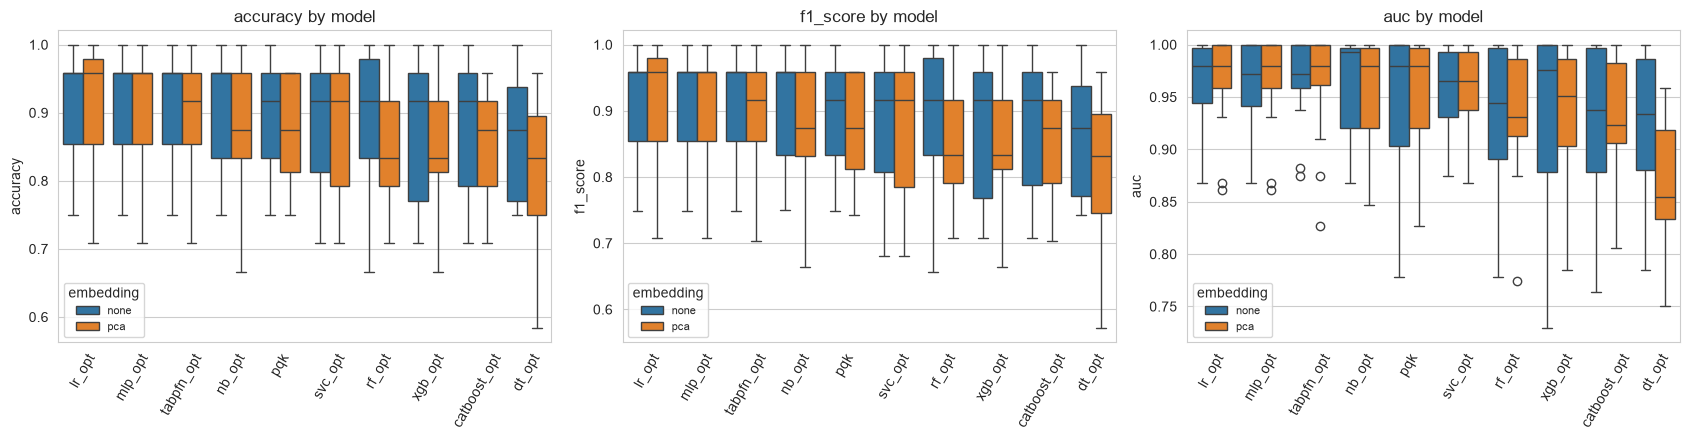

median f1 by model and embedding:


embeddings,none,pca
model,,
lr_opt,0.958,0.958
mlp_opt,0.958,0.958
tabpfn_opt,0.958,0.917
nb_opt,0.958,0.875
pqk,0.917,0.875
svc_opt,0.916,0.916
rf_opt,0.917,0.833
xgb_opt,0.917,0.833
catboost_opt,0.917,0.875


In [10]:
order = results.groupby("model")["f1_score"].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, metric in zip(axes, ("accuracy", "f1_score", "auc")):
    sns.boxplot(data=results, x="model", y=metric, order=order, hue="embeddings", ax=ax)
    ax.set_title(f"{metric} by model")
    ax.tick_params(axis="x", rotation=60)
    ax.set_xlabel("")
    ax.legend(title="embedding", fontsize=8)
plt.tight_layout()
plt.show()

print("median f1 by model and embedding:")
display(results.pivot_table(index="model", columns="embeddings",
                            values="f1_score", aggfunc="median").round(3).loc[order])

### Performance against the axis we varied

Each dataset is one clusters-per-class setting, so grouping by dataset shows whether the
geometry change actually cost the models anything. If it did not, there is nothing for
the correlation to find and the rest of the notebook would be measuring noise.

In [11]:
# Each dataset IS one clusters-per-class setting, so label the columns with it.
CLUSTERS = {"class_data-1.csv": 1, "class_data-2.csv": 2, "class_data-3.csv": 4}

by_dataset = results.pivot_table(index="model", columns="Dataset",
                                 values="f1_score", aggfunc="median").round(3)
by_dataset.columns = [f"clu={CLUSTERS[c]}" for c in by_dataset.columns]
display(by_dataset.loc[order])

spread = results.groupby("Dataset")["f1_score"].median()
spread.index = [f"clu={CLUSTERS[c]}" for c in spread.index]
print("median f1 across all models, per dataset:")
print(spread.round(3).to_string())
print(f"\nspread: {spread.max() - spread.min():.3f} f1 between the easiest and hardest dataset")
print("If that spread were ~0 there would be nothing for section 8 to correlate against.")

,clu=1,clu=2,clu=4
model,,,
lr_opt,0.958,0.958,0.791
mlp_opt,0.979,0.958,0.791
tabpfn_opt,0.958,0.958,0.812
nb_opt,0.958,0.958,0.808
pqk,0.937,0.958,0.790
svc_opt,0.958,0.916,0.738
rf_opt,0.937,0.937,0.750
xgb_opt,0.917,0.917,0.728
catboost_opt,0.958,0.917,0.766


median f1 across all models, per dataset:
clu=1    0.958
clu=2    0.958
clu=4    0.766

spread: 0.192 f1 between the easiest and hardest dataset
If that spread were ~0 there would be nothing for section 8 to correlate against.


## 8. Correlation: which data characteristics track performance?

`compute_results_correlation` groups the table by (model, embedding, datatype) and, within
each group, Spearman-correlates every complexity column against every metric. All three
datasets share the `class_data` datatype, so each group holds the 15 observations.

**The plot needs a feature subset.** The complexity block is ~140 columns wide now; a dot
plot over all of them is unreadable, which the v1 notebook did not have to deal with (it
had 31). So there are two plots below: the `task.` block on its own — 16 features, which
fits — then a selection ranked by correlation strength across all three blocks.

The per-block summary printed first is the one number to read before the plots: it says
whether the new block is carrying signal the other two do not already carry.

In [12]:
results_annotated, correlations = qbc.compute_results_correlation(
    results_df=results, correlation="spearman", thresh=0.7
)
print(f"{len(correlations)} correlations = "
      f"{correlations['model_embed_datatype'].nunique()} groups x "
      f"{correlations['metric'].nunique()} metrics x "
      f"{correlations['feature'].nunique()} features")

f1 = correlations[(correlations.metric == "f1_score") & correlations.correlation.notna()].copy()
f1["block"] = np.select(
    [f1.feature.str.startswith("task."), f1.feature.str.startswith("mfe.")],
    ["task.", "mfe."], default="native",
)
print("\nstrongest |Spearman rho| against f1_score, by block:")
display(f1.groupby("block")["correlation"].agg(
    n="size", max_abs=lambda s: s.abs().max(), median_abs=lambda s: s.abs().median()
).round(3))

11280 correlations = 20 groups x 4 metrics x 141 features

strongest |Spearman rho| against f1_score, by block:


,n,max_abs,median_abs
block,,,
mfe.,2070,0.859,0.412
native,150,0.821,0.422
task.,320,0.800,0.430


### 8a. The target-spectrum block alone

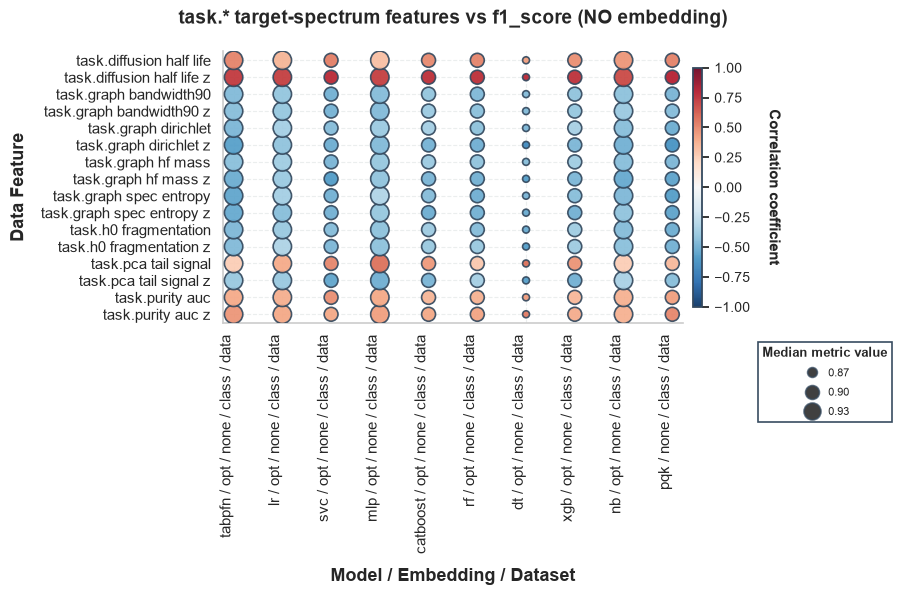

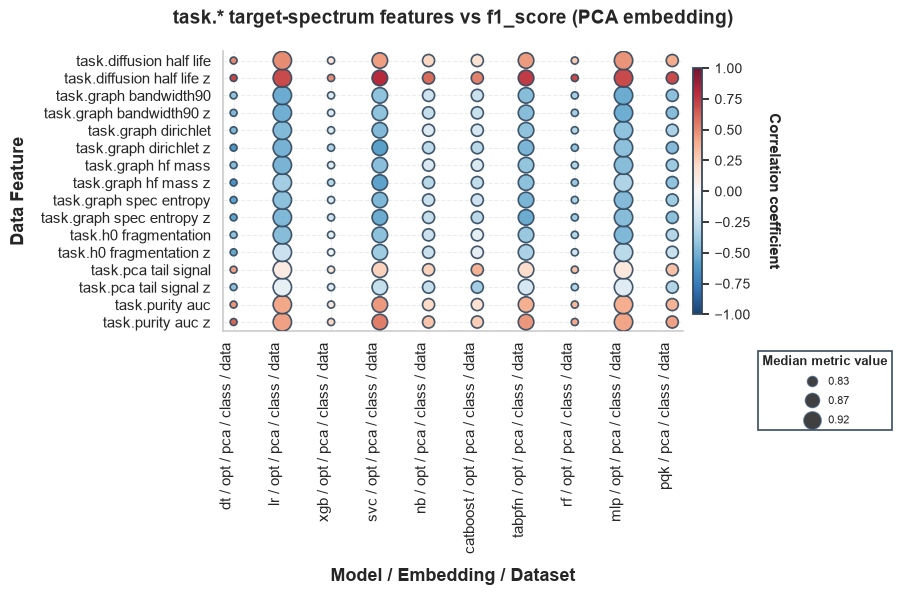

In [13]:
task_corr = correlations[correlations.feature.str.startswith("task.")]

for embedding in results["embeddings"].unique():
    subset = task_corr[task_corr.model_embed_datatype.str.contains(f"_{embedding}_")]
    if subset.empty:
        print(f"no rows for embedding {embedding}")
        continue
    label = "NO embedding" if embedding == "none" else f"{embedding.upper()} embedding"
    # show_plots=False plus displaying only .scatter: the function also builds two
    # heatmaps, and committing all three for each embedding made the notebook 1.9 MB of
    # near-duplicate figures. They remain available on the returned tuple.
    figures = qbc.plot_results_correlation(
        subset,
        metric="f1_score",
        title=f"task.* target-spectrum features vs f1_score ({label})",
        correlation_type="Color: Spearman rho;\nSize: median f1",
        size="median_metric",
        figsize=(9, 6),
        show_plots=False,
    )
    display(figures.scatter)

### 8b. Top features across all three blocks

Ranked by the strongest |rho| any group achieved, so the selection is driven by the data
rather than by which columns looked interesting.

Read the table below by **share of block**, not by count. `mfe.` contributes 115 of the
141 columns, so it would dominate any top-N list by arithmetic alone; what tells you
whether a block carries independent signal is the fraction of *its own* columns that get
there.

Two things are worth noticing when you run this, and they point in opposite directions:

- The `task.` block's **median** |rho| (printed in the previous cell) is competitive with
  the other two despite being a sixteenth of the width. A block whose columns were
  redundant with the pyMFE ones would sit below them, not level.
- But the **single strongest** features are `mfe.` ones. The target spectrum is broadly
  informative here rather than home to one standout predictor.

Neither observation is strong evidence on 15 observations across datasets that differ on
one axis. Section 9 says why.

top 22 of 132 features by max |rho|, per block:



,block_size,in_top,share_of_block
native,8,3,0.375
mfe.,108,18,0.167
task.,16,1,0.062



the 22 features themselves:
                            max_abs_rho   block
feature                                        
mfe.worst_node.sd                 0.859    mfe.
mfe.wg_dist.sd                    0.828    mfe.
Coefficient of Variation %        0.821  native
mfe.skewness.mean                 0.810    mfe.
task.diffusion_half_life_z        0.800   task.
mfe.median.mean                   0.792    mfe.
Mean Log Kernel Density           0.789  native
mfe.max.sd                        0.785    mfe.
Condition number                  0.782  native
mfe.best_node.sd                  0.781    mfe.
mfe.cov.mean                      0.762    mfe.
mfe.nr_norm                       0.761    mfe.
mfe.l3.mean                       0.758    mfe.
mfe.sd.mean                       0.755    mfe.
mfe.conceptvar.sd                 0.742    mfe.
mfe.int                           0.741    mfe.
mfe.var.mean                      0.733    mfe.
mfe.n2.sd                         0.732    mfe.
mfe.f4.mean

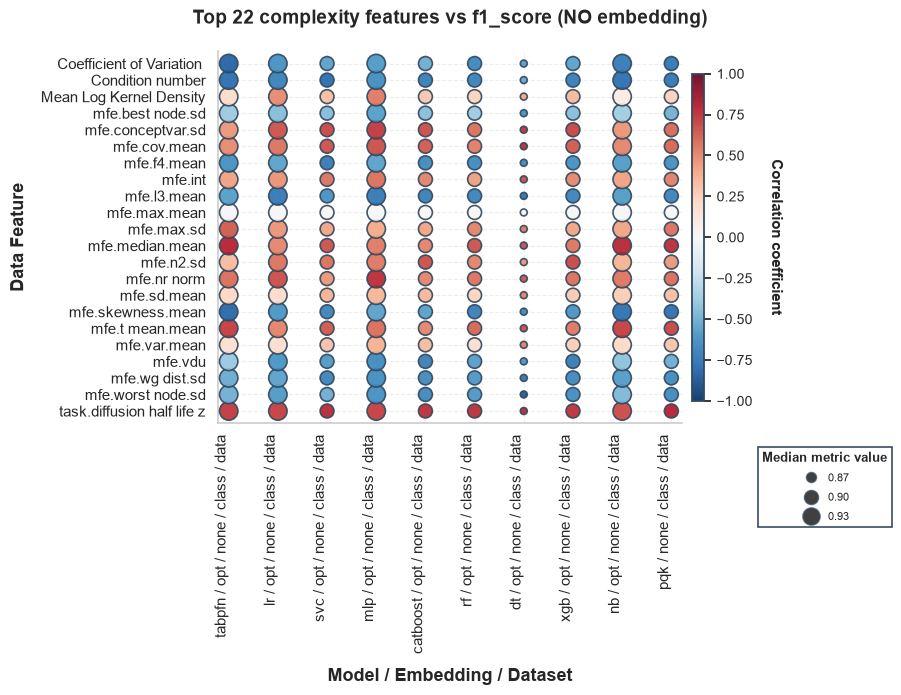

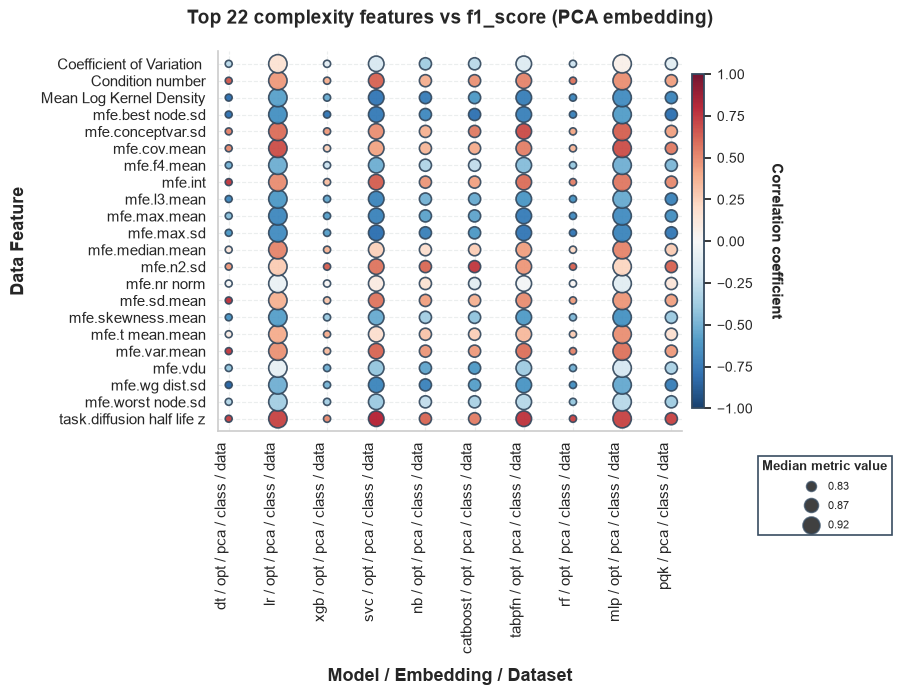

In [14]:
TOP_N = 22
strength = f1.groupby("feature")["correlation"].apply(lambda s: s.abs().max())
top = strength.sort_values(ascending=False).head(TOP_N).index


def block_of(names):
    names = pd.Index(names)
    return pd.Series(
        np.select([names.str.startswith("task."), names.str.startswith("mfe.")],
                  ["task.", "mfe."], default="native"), index=names)


# Raw counts favour whichever block has the most columns -- mfe. has 115 against task.'s
# 16 -- so the share of each block that reaches the top matters more than the count.
sizes = block_of(strength.index).value_counts()
hits = block_of(top).value_counts().reindex(sizes.index, fill_value=0)
print(f"top {TOP_N} of {len(strength)} features by max |rho|, per block:\n")
display(pd.DataFrame({
    "block_size": sizes,
    "in_top": hits,
    "share_of_block": (hits / sizes).round(3),
}).sort_values("share_of_block", ascending=False))

print(f"\nthe {TOP_N} features themselves:")
print(pd.DataFrame({"max_abs_rho": strength.loc[top].round(3),
                    "block": block_of(top)}).to_string())

for embedding in results["embeddings"].unique():
    subset = correlations[
        correlations.feature.isin(top)
        & correlations.model_embed_datatype.str.contains(f"_{embedding}_")
    ]
    if subset.empty:
        continue
    label = "NO embedding" if embedding == "none" else f"{embedding.upper()} embedding"
    figures = qbc.plot_results_correlation(
        subset,
        metric="f1_score",
        title=f"Top {TOP_N} complexity features vs f1_score ({label})",
        correlation_type="Color: Spearman rho;\nSize: median f1",
        size="median_metric",
        figsize=(9, 7),
        show_plots=False,
    )
    display(figures.scatter)

## 9. Reading this honestly

What the notebook has produced is 15 observations per group and a rank correlation over
them. Three cautions belong with the plots rather than after them:

1. **15 points.** A Spearman |rho| needs to clear roughly 0.52 to reach p < 0.05 at
   n = 15, and with ~140 features tested per group, some will clear it by chance. Treat
   the ranking as a shortlist, not a result.
2. **Most of the variation is between the three datasets**, not within the five splits of
   each. So a feature that correlates strongly may simply be one that tracks
   clusters-per-class — which is what we varied on purpose. That is a genuine signal
   about that axis, and *not* evidence the feature generalizes to other axes.
3. **The z-scored `task.` columns are the ones to trust first** where they disagree with
   their raw counterparts, because the raw value alone cannot separate a genuinely
   oscillatory target from a sparse geometry in which any label looks oscillatory.
4. **Block width is a confound in any top-N ranking.** `mfe.` has 115 columns against
   `task.`'s 16 and native's 10, so counting top-N membership measures block size as much
   as block quality. That is why section 8b reports the share of each block rather than
   the count, and why the median |rho| per block appears alongside the maximum.

To turn a shortlist into a result: more datasets along more than one axis, then check
whether the same features survive. `tutorial/QSage/` is the next step — it trains on a
table of exactly this shape to predict which model will win.

## Summary

This notebook:

1. Generated three datasets differing in one geometric property (clusters per class)
2. Profiled ten tuned models — including CatBoost and TabPFN — with Optuna, over 3
   datasets × 5 splits × 2 embeddings
3. Computed all three complexity blocks per split: hand-curated native, `mfe.`, and the
   `task.` target spectrum with its permutation controls
4. Correlated every complexity column against performance and compared the blocks

### Next steps

- **QSage** (`tutorial/QSage/`) — learn model selection from a table like this one
- **Full search spaces** — restore the shipped `n_trials: 50` and 5-fold CV in
  `configs/config.yaml`; expect roughly an order of magnitude more runtime
- **The expensive quantum models** — add `qsvc`, `vqc`, `qnn`, and set
  `tune_quantum: True` with a budget you have measured first
- **Tuning engines compared** — `tutorial/Hyperparameter_Tuning/optuna_vs_gridsearch.ipynb`